# predic_consumo_agua_v7

Complemento de interpretabilidad del modelo XGBoost final para la tesis:
**Aplicacion de Tecnicas de Machine Learning para la Prediccion del Consumo Hidrico en la Ciudad de Bogota**.

Este notebook no reemplaza los experimentos previos. Su objetivo es complementar la interpretacion del XGBoost seleccionado mediante tres enfoques de importancia: importancia nativa de XGBoost, importancia por permutacion y valores SHAP.


## 1. Criterio metodologico

Se replica el flujo del modelo XGBoost final de `predic_consumo_agua_v5.ipynb`: base `df_consumo_bime_clima_v3.xlsx`, variable objetivo `consumo_promedio`, transformacion `log1p` del target, particion 70/15/15 con `random_state=42`, imputacion ajustada solo con entrenamiento y configuracion seleccionada de XGBoost.

La validacion Leave-One-Localidad-Out de `predic_consumo_agua_v6.ipynb` se utiliza como referencia metodologica para interpretar el alcance espacial del modelo. En particular, `latitud` y `longitud` se interpretan como variables con contribucion predictiva dentro del dominio observado, no como evidencia causal ni como garantia de generalizacion hacia localidades no observadas.


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

import xgboost
from xgboost import XGBRegressor
import shap

plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)


## 2. Configuracion reproducible del experimento


In [2]:
DATA_PATH = Path("df_consumo_bime_clima_v3.xlsx")
TARGET = "consumo_promedio"
RANDOM_STATE = 42

LEAKAGE_COLUMNS = [
    "metros_cubicos",
    "facturas",
    "suscriptores_facturados",
    "suscriptores_con_medidor",
]

REDUNDANT_OR_DERIVED_COLUMNS = [
    "T2MWET", "T2MDEW", "T2M_RANGE",
    "WS10M_MAX", "WS10M_MIN", "WS10M_RANGE",
    "WS2M_MAX", "WS2M_MIN", "WS2M_RANGE",
    "WD10M", "WD2M",
    "ALLSKY_SFC_PAR_TOT", "CLRSKY_SFC_PAR_TOT",
    "ALLSKY_SFC_SW_DIFF", "ALLSKY_SFC_SW_DNI",
    "ALLSKY_SFC_UVA", "ALLSKY_SFC_UVB", "ALLSKY_SFC_UV_INDEX",
    "CLRSKY_SFC_SW_DWN", "TOA_SW_DWN",
]

# Configuracion optima seleccionada en predic_consumo_agua_v5.ipynb.
XGB_FINAL_PARAMS = {
    "n_estimators": 400,
    "learning_rate": 0.05,
    "max_depth": 3,
    "min_child_weight": 3,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "objective": "reg:squarederror",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

def make_xgb_model(y_train_log):
    return XGBRegressor(**XGB_FINAL_PARAMS)

df_raw = pd.read_excel(DATA_PATH)
print("Version XGBoost:", xgboost.__version__)
print("Version SHAP:", shap.__version__)
print("Dataset cargado:", DATA_PATH)
print("Dimensiones iniciales:", df_raw.shape)
display(df_raw.head())


Version XGBoost: 2.1.4
Version SHAP: 0.49.1
Dataset cargado: df_consumo_bime_clima_v3.xlsx
Dimensiones iniciales: (596, 49)


,año,localidad,BIMESTRE,metros_cubicos,facturas,consumo_promedio,suscriptores_facturados,suscriptores_con_medidor,latitud,longitud,ALLSKY_SFC_LW_DWN,ALLSKY_SFC_PAR_TOT,ALLSKY_SFC_SW_DIFF,ALLSKY_SFC_SW_DNI,ALLSKY_SFC_SW_DWN,ALLSKY_SFC_UVA,ALLSKY_SFC_UVB,ALLSKY_SFC_UV_INDEX,ALLSKY_SRF_ALB,CLOUD_AMT,CLRSKY_SFC_PAR_TOT,CLRSKY_SFC_SW_DWN,GWETPROF,GWETROOT,GWETTOP,ONI,PRECTOTCORR,PRECTOTCORR_SUM,PS,QV2M,RH2M,T2M,T2MDEW,T2MWET,T2M_MAX,T2M_MIN,T2M_RANGE,TOA_SW_DWN,TS,WD10M,WD2M,WS10M,WS10M_MAX,WS10M_MIN,WS10M_RANGE,WS2M,WS2M_MAX,WS2M_MIN,WS2M_RANGE
0,2020,USAQUEN,1,4653292,213354,10.905097,212731.0,215097,4.73197,-74.05163,31.615,8.98,7.795,14.525,19.135,1.29,0.04,2.515,0.15,62.185,11.51,25.34,0.775,0.765,0.760,0.49,2.015,59.16,79.585,11.865,83.595,16.04,12.865,14.455,22.470,8.820,8.605,35.32,16.32,89.65,94.8,2.310,6.405,0.140,3.07,1.395,4.175,0.065,2.085
1,2020,CHAPINERO,1,2281601,93362,12.219109,93016.0,93684,4.67040,-74.04338,31.615,8.98,7.795,14.525,19.135,1.29,0.04,2.515,0.15,62.185,11.51,25.34,0.775,0.765,0.760,0.49,2.015,59.16,79.585,11.865,83.595,16.04,12.865,14.455,22.470,8.820,8.605,35.32,16.32,89.65,94.8,2.310,6.405,0.140,3.07,1.395,4.175,0.065,2.085
2,2020,SANTA FE,1,843631,33789,12.483811,33524.0,34703,4.60947,-74.08135,31.615,8.98,7.795,14.525,19.135,1.29,0.04,2.515,0.15,62.185,11.51,25.34,0.705,0.640,0.655,0.49,2.665,77.95,82.335,12.860,78.225,19.06,14.615,16.835,27.045,9.945,10.460,35.32,19.24,78.20,78.8,2.275,6.650,0.205,2.31,1.430,4.735,0.150,1.945
3,2020,SAN CRISTOBAL,1,1771678,80676,10.980205,80311.0,81072,4.58843,-74.07080,31.615,8.98,7.795,14.525,19.135,1.29,0.04,2.515,0.15,62.185,11.51,25.34,0.705,0.640,0.655,0.49,2.665,77.95,82.335,12.860,78.225,19.06,14.615,16.835,27.045,9.945,10.460,35.32,19.24,78.20,78.8,2.275,6.650,0.205,2.31,1.430,4.735,0.150,1.945
4,2020,USME,1,1570282,78240,10.035033,77876.0,79159,4.53286,-74.11451,31.615,8.98,7.795,14.525,19.135,1.29,0.04,2.515,0.15,62.185,11.51,25.34,0.705,0.640,0.655,0.49,2.665,77.95,82.335,12.860,78.225,19.06,14.615,16.835,27.045,9.945,10.460,35.32,19.24,78.20,78.8,2.275,6.650,0.205,2.31,1.430,4.735,0.150,1.945


## 3. Preprocesamiento sin fuga de informacion


In [3]:
def regression_metrics_original_scale(y_true_log, y_pred_log):
    y_true = np.expm1(np.asarray(y_true_log, dtype=float))
    y_pred = np.expm1(np.asarray(y_pred_log, dtype=float))
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }


def prepare_model_frame(raw_df, include_spatial=True, keep_localidad=False):
    data = raw_df.copy()
    if TARGET not in data.columns:
        raise ValueError(f"No existe la variable objetivo {TARGET!r}.")

    columns_to_drop = [c for c in LEAKAGE_COLUMNS + REDUNDANT_OR_DERIVED_COLUMNS if c in data.columns]
    if not keep_localidad and "localidad" in data.columns:
        columns_to_drop.append("localidad")
    if not include_spatial:
        columns_to_drop.extend([c for c in ["latitud", "longitud"] if c in data.columns and c not in columns_to_drop])

    data = data.drop(columns=columns_to_drop)
    data = data[data[TARGET].notna()].reset_index(drop=True)

    y = pd.to_numeric(data[TARGET], errors="coerce")
    X = data.drop(columns=[TARGET]).copy()

    if "BIMESTRE" in X.columns:
        X["BIMESTRE"] = pd.to_numeric(X["BIMESTRE"], errors="coerce")
        X["BIMESTRE_sin"] = np.sin(2 * np.pi * X["BIMESTRE"] / 6)
        X["BIMESTRE_cos"] = np.cos(2 * np.pi * X["BIMESTRE"] / 6)
        X = X.drop(columns=["BIMESTRE"])

    for col in X.columns:
        if col != "localidad":
            X[col] = pd.to_numeric(X[col], errors="coerce")

    valid_target = y.notna()
    X = X.loc[valid_target].reset_index(drop=True)
    y = y.loc[valid_target].reset_index(drop=True)

    if (y < 0).any():
        raise ValueError("No se puede aplicar log1p porque existen valores negativos en el target.")

    y_log = np.log1p(y)
    return X, y_log, columns_to_drop


def split_and_impute(X, y_log):
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y_log, test_size=0.30, random_state=RANDOM_STATE
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE
    )

    imputer = SimpleImputer(strategy="median")
    X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns, index=X_train.index)
    X_val_imp = pd.DataFrame(imputer.transform(X_val), columns=X.columns, index=X_val.index)
    X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X.columns, index=X_test.index)
    return X_train_imp, X_val_imp, X_test_imp, y_train, y_val, y_test, imputer


X, y_log, dropped_columns = prepare_model_frame(df_raw, include_spatial=True, keep_localidad=False)
X_train, X_val, X_test, y_train, y_val, y_test, imputer = split_and_impute(X, y_log)

print("Columnas eliminadas por metodologia:")
for col in dropped_columns:
    print(" -", col)

print("\nVariables predictoras definitivas:", X.shape[1])
print(X.columns.tolist())
print("\nTamanos:")
print("X:", X.shape)
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)


Columnas eliminadas por metodologia:
 - metros_cubicos
 - facturas
 - suscriptores_facturados
 - suscriptores_con_medidor
 - T2MWET
 - T2MDEW
 - T2M_RANGE
 - WS10M_MAX
 - WS10M_MIN
 - WS10M_RANGE
 - WS2M_MAX
 - WS2M_MIN
 - WS2M_RANGE
 - WD10M
 - WD2M
 - ALLSKY_SFC_PAR_TOT
 - CLRSKY_SFC_PAR_TOT
 - ALLSKY_SFC_SW_DIFF
 - ALLSKY_SFC_SW_DNI
 - ALLSKY_SFC_UVA
 - ALLSKY_SFC_UVB
 - ALLSKY_SFC_UV_INDEX
 - CLRSKY_SFC_SW_DWN
 - TOA_SW_DWN
 - localidad

Variables predictoras definitivas: 24
['año', 'latitud', 'longitud', 'ALLSKY_SFC_LW_DWN', 'ALLSKY_SFC_SW_DWN', 'ALLSKY_SRF_ALB', 'CLOUD_AMT', 'GWETPROF', 'GWETROOT', 'GWETTOP', 'ONI', 'PRECTOTCORR', 'PRECTOTCORR_SUM', 'PS', 'QV2M', 'RH2M', 'T2M', 'T2M_MAX', 'T2M_MIN', 'TS', 'WS10M', 'WS2M', 'BIMESTRE_sin', 'BIMESTRE_cos']

Tamanos:
X: (596, 24)
Train: (417, 24) (417,)
Val:   (89, 24) (89,)
Test:  (90, 24) (90,)


## 4. Entrenamiento del XGBoost final


In [4]:
xgb_final = make_xgb_model(y_train)
xgb_final.fit(
    X_train,
    y_train.values,
    eval_set=[(X_val, y_val.values)],
    verbose=False,
)

pred_train = xgb_final.predict(X_train)
pred_val = xgb_final.predict(X_val)
pred_test = xgb_final.predict(X_test)

metrics_rows = []
for split_name, y_true, y_pred in [
    ("train", y_train, pred_train),
    ("validation", y_val, pred_val),
    ("test", y_test, pred_test),
]:
    metrics_rows.append({"conjunto": split_name, **regression_metrics_original_scale(y_true, y_pred)})

metricas_xgb_final = pd.DataFrame(metrics_rows)
display(metricas_xgb_final)


,conjunto,MAE,RMSE,R2
0,train,0.231972,0.348755,0.983716
1,validation,0.991093,2.852055,0.591712
2,test,0.423633,0.746701,0.890315


## 5. Importancia nativa de XGBoost


,variable,importancia_nativa,ranking_nativo
0,latitud,0.114952,1
1,BIMESTRE_sin,0.088439,2
2,PS,0.074756,3
3,T2M,0.063075,4
4,ONI,0.059797,5
5,T2M_MIN,0.058305,6
6,longitud,0.058034,7
7,GWETROOT,0.051562,8
8,GWETPROF,0.049352,9
9,T2M_MAX,0.045433,10


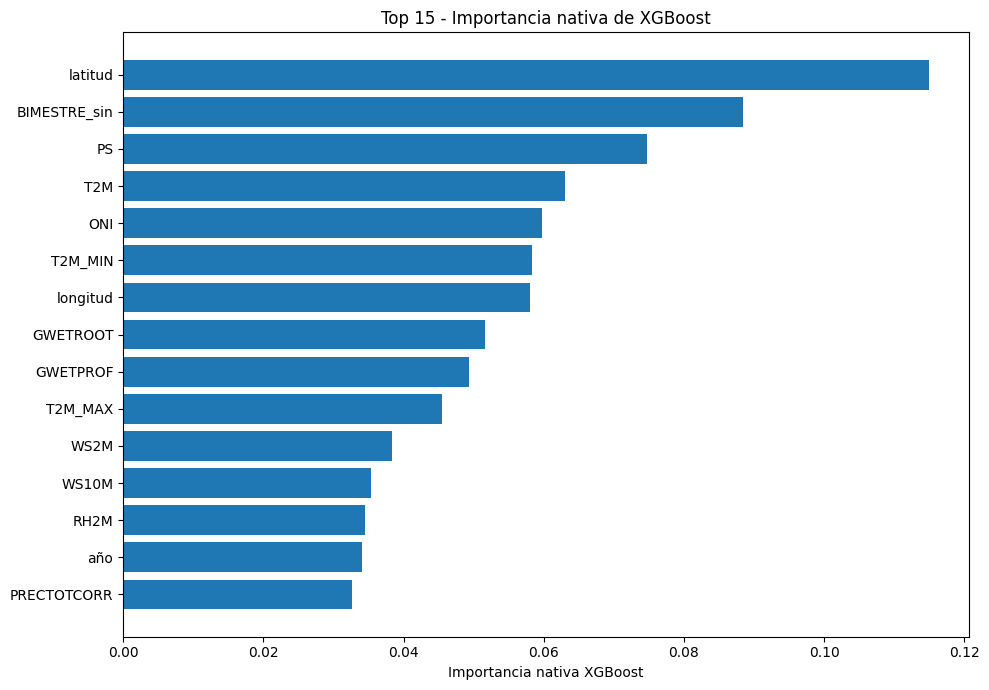

In [5]:
importancia_nativa = (
    pd.DataFrame({
        "variable": X_train.columns,
        "importancia_nativa": xgb_final.feature_importances_,
    })
    .sort_values("importancia_nativa", ascending=False)
    .reset_index(drop=True)
)
importancia_nativa["ranking_nativo"] = np.arange(1, len(importancia_nativa) + 1)
importancia_nativa.to_csv("importancia_xgboost_nativa.csv", index=False, encoding="utf-8-sig")

display(importancia_nativa)

plt.figure(figsize=(10, 7))
top_native = importancia_nativa.head(15).sort_values("importancia_nativa", ascending=True)
plt.barh(top_native["variable"], top_native["importancia_nativa"])
plt.xlabel("Importancia nativa XGBoost")
plt.title("Top 15 - Importancia nativa de XGBoost")
plt.tight_layout()
plt.show()


## 6. Importancia por permutacion en el conjunto de prueba


,variable,perdida_mae_media,perdida_mae_std,perdida_r2_media,perdida_r2_std,ranking_permutacion_mae
0,latitud,1.197579,0.098766,0.919847,0.134526,1
1,longitud,0.806470,0.073725,0.466984,0.058058,2
2,RH2M,0.061726,0.018319,0.016932,0.014236,3
3,BIMESTRE_sin,0.060330,0.022062,0.024058,0.030514,4
4,PS,0.052262,0.028623,0.010406,0.020472,5
5,año,0.041517,0.020896,-0.011583,0.021171,6
6,PRECTOTCORR,0.031413,0.013665,0.024736,0.014051,7
7,T2M,0.028060,0.013668,-0.008386,0.009233,8
8,WS2M,0.025147,0.011270,0.007164,0.006479,9
9,ONI,0.023923,0.026862,-0.016078,0.024947,10


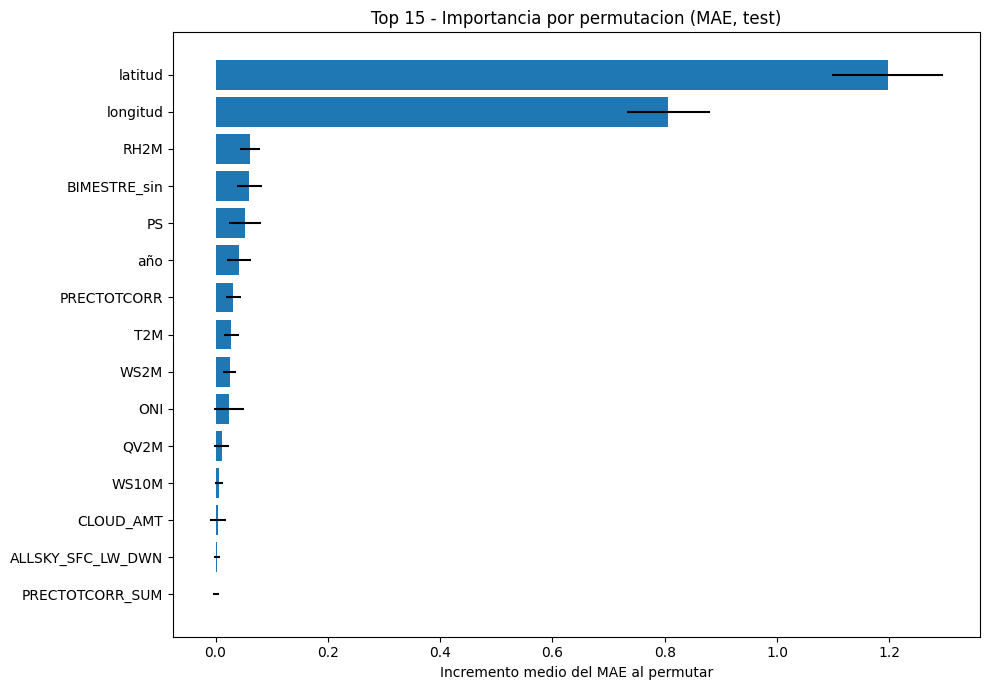

In [6]:
def neg_mae_original_scorer(estimator, X_eval, y_eval_log):
    pred_log = estimator.predict(X_eval)
    return -mean_absolute_error(np.expm1(y_eval_log), np.expm1(pred_log))


def r2_original_scorer(estimator, X_eval, y_eval_log):
    pred_log = estimator.predict(X_eval)
    return r2_score(np.expm1(y_eval_log), np.expm1(pred_log))


perm_mae = permutation_importance(
    xgb_final,
    X_test,
    y_test.values,
    scoring=neg_mae_original_scorer,
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

perm_r2 = permutation_importance(
    xgb_final,
    X_test,
    y_test.values,
    scoring=r2_original_scorer,
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

importancia_permutacion = pd.DataFrame({
    "variable": X_test.columns,
    "perdida_mae_media": perm_mae.importances_mean,
    "perdida_mae_std": perm_mae.importances_std,
    "perdida_r2_media": perm_r2.importances_mean,
    "perdida_r2_std": perm_r2.importances_std,
}).sort_values("perdida_mae_media", ascending=False).reset_index(drop=True)
importancia_permutacion["ranking_permutacion_mae"] = np.arange(1, len(importancia_permutacion) + 1)

importancia_permutacion.to_csv("importancia_permutacion_xgboost.csv", index=False, encoding="utf-8-sig")
display(importancia_permutacion)

plt.figure(figsize=(10, 7))
top_perm = importancia_permutacion.head(15).sort_values("perdida_mae_media", ascending=True)
plt.barh(top_perm["variable"], top_perm["perdida_mae_media"], xerr=top_perm["perdida_mae_std"])
plt.xlabel("Incremento medio del MAE al permutar")
plt.title("Top 15 - Importancia por permutacion (MAE, test)")
plt.tight_layout()
plt.show()


## 7. Importancia global con SHAP


,variable,shap_abs_medio,ranking_shap
0,latitud,0.075487,1
1,longitud,0.054132,2
2,BIMESTRE_sin,0.012240,3
3,año,0.011952,4
4,ONI,0.011282,5
5,T2M,0.009202,6
6,PS,0.008871,7
7,PRECTOTCORR,0.008044,8
8,RH2M,0.007897,9
9,CLOUD_AMT,0.005418,10


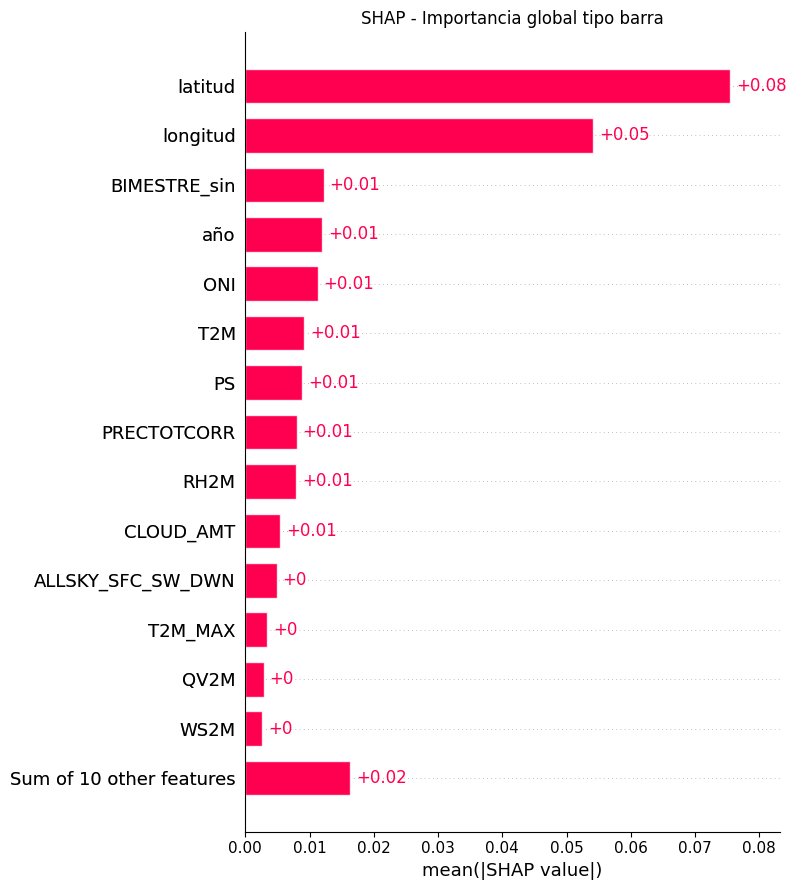

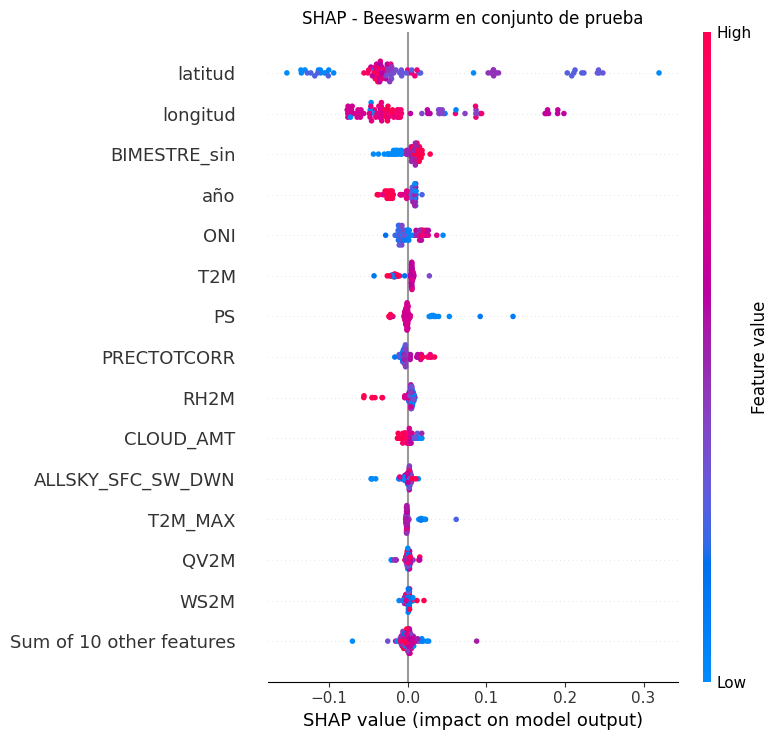

In [7]:
explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_test)
shap_values = np.asarray(shap_values)

importancia_shap = (
    pd.DataFrame({
        "variable": X_test.columns,
        "shap_abs_medio": np.abs(shap_values).mean(axis=0),
    })
    .sort_values("shap_abs_medio", ascending=False)
    .reset_index(drop=True)
)
importancia_shap["ranking_shap"] = np.arange(1, len(importancia_shap) + 1)
importancia_shap.to_csv("importancia_shap_xgboost.csv", index=False, encoding="utf-8-sig")
display(importancia_shap)

shap_explanation = shap.Explanation(
    values=shap_values,
    base_values=np.repeat(explainer.expected_value, X_test.shape[0]),
    data=X_test.values,
    feature_names=X_test.columns.tolist(),
)

shap.plots.bar(shap_explanation, max_display=15, show=False)
plt.title("SHAP - Importancia global tipo barra")
plt.tight_layout()
plt.show()

shap.plots.beeswarm(shap_explanation, max_display=15, show=False)
plt.title("SHAP - Beeswarm en conjunto de prueba")
plt.tight_layout()
plt.show()


## 8. Comparacion de rankings de importancia


In [8]:
comparacion_importancias = (
    importancia_nativa[["variable", "importancia_nativa", "ranking_nativo"]]
    .merge(
        importancia_permutacion[[
            "variable", "perdida_mae_media", "perdida_mae_std",
            "perdida_r2_media", "perdida_r2_std", "ranking_permutacion_mae"
        ]],
        on="variable",
        how="outer",
    )
    .merge(
        importancia_shap[["variable", "shap_abs_medio", "ranking_shap"]],
        on="variable",
        how="outer",
    )
)

TOP_N = 10
comparacion_importancias["top_nativo"] = comparacion_importancias["ranking_nativo"] <= TOP_N
comparacion_importancias["top_permutacion"] = comparacion_importancias["ranking_permutacion_mae"] <= TOP_N
comparacion_importancias["top_shap"] = comparacion_importancias["ranking_shap"] <= TOP_N
comparacion_importancias["apariciones_top10"] = comparacion_importancias[[
    "top_nativo", "top_permutacion", "top_shap"
]].sum(axis=1)
comparacion_importancias = comparacion_importancias.sort_values(
    ["apariciones_top10", "ranking_permutacion_mae", "ranking_shap", "ranking_nativo"],
    ascending=[False, True, True, True],
).reset_index(drop=True)

variables_consistentes = comparacion_importancias.loc[
    comparacion_importancias["apariciones_top10"] >= 2,
    "variable"
].tolist()

comparacion_importancias.to_csv("comparacion_importancias_xgboost.csv", index=False, encoding="utf-8-sig")
display(comparacion_importancias)

print("Variables en el top 10 de al menos dos metodos:")
for variable in variables_consistentes:
    print(" -", variable)


,variable,importancia_nativa,ranking_nativo,perdida_mae_media,perdida_mae_std,perdida_r2_media,perdida_r2_std,ranking_permutacion_mae,shap_abs_medio,ranking_shap,top_nativo,top_permutacion,top_shap,apariciones_top10
0,latitud,0.114952,1,1.197579,0.098766,0.919847,0.134526,1,0.075487,1,True,True,True,3
1,longitud,0.058034,7,0.806470,0.073725,0.466984,0.058058,2,0.054132,2,True,True,True,3
2,BIMESTRE_sin,0.088439,2,0.060330,0.022062,0.024058,0.030514,4,0.012240,3,True,True,True,3
3,PS,0.074756,3,0.052262,0.028623,0.010406,0.020472,5,0.008871,7,True,True,True,3
4,T2M,0.063075,4,0.028060,0.013668,-0.008386,0.009233,8,0.009202,6,True,True,True,3
5,ONI,0.059797,5,0.023923,0.026862,-0.016078,0.024947,10,0.011282,5,True,True,True,3
6,RH2M,0.034543,13,0.061726,0.018319,0.016932,0.014236,3,0.007897,9,False,True,True,2
7,año,0.034018,14,0.041517,0.020896,-0.011583,0.021171,6,0.011952,4,False,True,True,2
8,PRECTOTCORR,0.032677,15,0.031413,0.013665,0.024736,0.014051,7,0.008044,8,False,True,True,2
9,WS2M,0.038287,11,0.025147,0.011270,0.007164,0.006479,9,0.002656,14,False,True,False,1


Variables en el top 10 de al menos dos metodos:
 - latitud
 - longitud
 - BIMESTRE_sin
 - PS
 - T2M
 - ONI
 - RH2M
 - año
 - PRECTOTCORR


## 9. Comparacion del modelo con y sin variables espaciales


In [9]:
def train_evaluate_xgb_variant(include_spatial):
    X_variant, y_variant_log, dropped_variant = prepare_model_frame(
        df_raw, include_spatial=include_spatial, keep_localidad=False
    )
    X_train_v, X_val_v, X_test_v, y_train_v, y_val_v, y_test_v, _ = split_and_impute(X_variant, y_variant_log)

    model = make_xgb_model(y_train_v)
    model.fit(
        X_train_v,
        y_train_v.values,
        eval_set=[(X_val_v, y_val_v.values)],
        verbose=False,
    )

    rows = []
    for split_name, X_split, y_split in [
        ("train", X_train_v, y_train_v),
        ("validation", X_val_v, y_val_v),
        ("test", X_test_v, y_test_v),
    ]:
        pred = model.predict(X_split)
        rows.append({
            "modelo": "con_latitud_longitud" if include_spatial else "sin_latitud_longitud",
            "conjunto": split_name,
            "n_features": X_variant.shape[1],
            **regression_metrics_original_scale(y_split, pred),
        })
    return pd.DataFrame(rows)


comparacion_espacial = pd.concat([
    train_evaluate_xgb_variant(include_spatial=True),
    train_evaluate_xgb_variant(include_spatial=False),
], ignore_index=True)

comparacion_espacial.to_csv("comparacion_xgboost_con_sin_espaciales.csv", index=False, encoding="utf-8-sig")
display(comparacion_espacial)

print("Comparacion en conjunto de prueba:")
display(comparacion_espacial[comparacion_espacial["conjunto"] == "test"].reset_index(drop=True))


,modelo,conjunto,n_features,MAE,RMSE,R2
0,con_latitud_longitud,train,24,0.231972,0.348755,0.983716
1,con_latitud_longitud,validation,24,0.991093,2.852055,0.591712
2,con_latitud_longitud,test,24,0.423633,0.746701,0.890315
3,sin_latitud_longitud,train,22,1.265219,1.906247,0.513514
4,sin_latitud_longitud,validation,22,2.473395,4.375455,0.039057
5,sin_latitud_longitud,test,22,1.531498,2.108955,0.125043


Comparacion en conjunto de prueba:


,modelo,conjunto,n_features,MAE,RMSE,R2
0,con_latitud_longitud,test,24,0.423633,0.746701,0.890315
1,sin_latitud_longitud,test,22,1.531498,2.108955,0.125043


## 10. Relacion con la validacion espacial Leave-One-Localidad-Out


In [10]:
lolo_path = Path("resultados_leave_one_localidad_out.csv")
lolo_sin_sumapaz_path = Path("resultados_leave_one_localidad_out_sin_sumapaz.csv")

if lolo_path.exists():
    lolo = pd.read_csv(lolo_path)
    resumen_lolo = lolo[["MAE_test", "RMSE_test", "R2_test"]].agg(["mean", "median"]).round(4)
    print("Resumen LOLO con todas las localidades:")
    display(resumen_lolo)
else:
    lolo = None
    print("No se encontro resultados_leave_one_localidad_out.csv")

if lolo_sin_sumapaz_path.exists():
    lolo_sin_sumapaz = pd.read_csv(lolo_sin_sumapaz_path)
    resumen_lolo_sin_sumapaz = lolo_sin_sumapaz[["MAE_test", "RMSE_test", "R2_test"]].agg(["mean", "median"]).round(4)
    print("Resumen LOLO sin Sumapaz:")
    display(resumen_lolo_sin_sumapaz)
else:
    lolo_sin_sumapaz = None
    print("No se encontro resultados_leave_one_localidad_out_sin_sumapaz.csv")

print(
    "Interpretacion: una importancia alta de latitud/longitud bajo particion aleatoria "
    "debe leerse como contribucion predictiva dentro de localidades conocidas. "
    "Los resultados LOLO muestran que esa contribucion no equivale a generalizacion "
    "hacia localidades completamente no observadas."
)


Resumen LOLO con todas las localidades:


,MAE_test,RMSE_test,R2_test
mean,2.2780,2.5129,-48.5812
median,0.9091,0.9962,-2.5484


Resumen LOLO sin Sumapaz:


,MAE_test,RMSE_test,R2_test
mean,1.5813,1.6734,-11.6516
median,0.8882,0.9250,-2.7223


Interpretacion: una importancia alta de latitud/longitud bajo particion aleatoria debe leerse como contribucion predictiva dentro de localidades conocidas. Los resultados LOLO muestran que esa contribucion no equivale a generalizacion hacia localidades completamente no observadas.


## 11. Sintesis academica y texto propuesto para la tesis


In [11]:
def get_rank(df, variable, rank_col, value_col):
    row = df.loc[df["variable"] == variable]
    if row.empty:
        return "no aparece", np.nan
    return int(row.iloc[0][rank_col]), float(row.iloc[0][value_col])


lat_native = get_rank(importancia_nativa, "latitud", "ranking_nativo", "importancia_nativa")
lon_native = get_rank(importancia_nativa, "longitud", "ranking_nativo", "importancia_nativa")
lat_perm = get_rank(importancia_permutacion, "latitud", "ranking_permutacion_mae", "perdida_mae_media")
lon_perm = get_rank(importancia_permutacion, "longitud", "ranking_permutacion_mae", "perdida_mae_media")
lat_shap = get_rank(importancia_shap, "latitud", "ranking_shap", "shap_abs_medio")
lon_shap = get_rank(importancia_shap, "longitud", "ranking_shap", "shap_abs_medio")

test_metrics = metricas_xgb_final.loc[metricas_xgb_final["conjunto"] == "test"].iloc[0]
test_comp = comparacion_espacial[comparacion_espacial["conjunto"] == "test"].copy()

texto = f'''
### Sintesis academica de los hallazgos

El modelo XGBoost final entrenado con la particion aleatoria 70/15/15 alcanzo en el conjunto de prueba un MAE de {test_metrics["MAE"]:.4f}, un RMSE de {test_metrics["RMSE"]:.4f} y un R2 de {test_metrics["R2"]:.4f}, calculados en la escala original de `consumo_promedio` despues de aplicar `expm1`. Estos resultados confirman el buen desempeno del modelo dentro del dominio observado de localidades de Bogota.

La importancia nativa de XGBoost, la importancia por permutacion y SHAP ofrecen lecturas complementarias. La importancia nativa resume el uso interno de las variables dentro de los arboles; la permutacion mide la perdida de desempeno cuando se altera una variable en el conjunto de prueba; y SHAP estima la contribucion media absoluta de cada variable sobre las predicciones del modelo. Las variables con contribucion consistente en al menos dos metodos fueron: {", ".join(variables_consistentes) if variables_consistentes else "no se identificaron variables comunes bajo el criterio definido"}.

En particular, `latitud` tuvo ranking nativo {lat_native[0]} con importancia {lat_native[1]:.6f}, ranking por permutacion {lat_perm[0]} con perdida media de MAE {lat_perm[1]:.6f}, y ranking SHAP {lat_shap[0]} con valor SHAP absoluto medio {lat_shap[1]:.6f}. `longitud` tuvo ranking nativo {lon_native[0]} con importancia {lon_native[1]:.6f}, ranking por permutacion {lon_perm[0]} con perdida media de MAE {lon_perm[1]:.6f}, y ranking SHAP {lon_shap[0]} con valor SHAP absoluto medio {lon_shap[1]:.6f}.

La comparacion con y sin variables espaciales muestra que `latitud` y `longitud` aportan capacidad para reducir el error bajo particion aleatoria. No obstante, esta contribucion predictiva debe interpretarse junto con la validacion Leave-One-Localidad-Out. Los resultados LOLO existentes muestran que el desempeno cae cuando una localidad completa se excluye del entrenamiento. Por tanto, las coordenadas pueden actuar como identificadores indirectos de las localidades conocidas y su relevancia no debe presentarse como causalidad ni como evidencia de generalizacion espacial hacia localidades nuevas.

Texto propuesto para la tesis: "La interpretacion del modelo XGBoost se complemento mediante importancia nativa, importancia por permutacion y valores SHAP. Los tres enfoques permiten analizar la contribucion predictiva de las variables desde perspectivas distintas. Los resultados muestran que las variables espaciales, especialmente latitud y longitud, tienen un papel relevante en las predicciones bajo particion aleatoria. Sin embargo, dado que la validacion Leave-One-Localidad-Out evidencio bajo desempeno cuando se excluyen localidades completas, estas variables deben interpretarse como representaciones espaciales utiles para interpolar dentro de localidades observadas, no como relaciones causales ni como garantia de extrapolacion territorial. En consecuencia, el modelo es metodologicamente defendible para apoyar estimaciones dentro del dominio espacial representado en los datos, pero requiere validaciones adicionales antes de aplicarse a localidades no observadas."
'''

display(Markdown(texto))



### Sintesis academica de los hallazgos

El modelo XGBoost final entrenado con la particion aleatoria 70/15/15 alcanzo en el conjunto de prueba un MAE de 0.4236, un RMSE de 0.7467 y un R2 de 0.8903, calculados en la escala original de `consumo_promedio` despues de aplicar `expm1`. Estos resultados confirman el buen desempeno del modelo dentro del dominio observado de localidades de Bogota.

La importancia nativa de XGBoost, la importancia por permutacion y SHAP ofrecen lecturas complementarias. La importancia nativa resume el uso interno de las variables dentro de los arboles; la permutacion mide la perdida de desempeno cuando se altera una variable en el conjunto de prueba; y SHAP estima la contribucion media absoluta de cada variable sobre las predicciones del modelo. Las variables con contribucion consistente en al menos dos metodos fueron: latitud, longitud, BIMESTRE_sin, PS, T2M, ONI, RH2M, año, PRECTOTCORR.

En particular, `latitud` tuvo ranking nativo 1 con importancia 0.114952, ranking por permutacion 1 con perdida media de MAE 1.197579, y ranking SHAP 1 con valor SHAP absoluto medio 0.075487. `longitud` tuvo ranking nativo 7 con importancia 0.058034, ranking por permutacion 2 con perdida media de MAE 0.806470, y ranking SHAP 2 con valor SHAP absoluto medio 0.054132.

La comparacion con y sin variables espaciales muestra que `latitud` y `longitud` aportan capacidad para reducir el error bajo particion aleatoria. No obstante, esta contribucion predictiva debe interpretarse junto con la validacion Leave-One-Localidad-Out. Los resultados LOLO existentes muestran que el desempeno cae cuando una localidad completa se excluye del entrenamiento. Por tanto, las coordenadas pueden actuar como identificadores indirectos de las localidades conocidas y su relevancia no debe presentarse como causalidad ni como evidencia de generalizacion espacial hacia localidades nuevas.

Texto propuesto para la tesis: "La interpretacion del modelo XGBoost se complemento mediante importancia nativa, importancia por permutacion y valores SHAP. Los tres enfoques permiten analizar la contribucion predictiva de las variables desde perspectivas distintas. Los resultados muestran que las variables espaciales, especialmente latitud y longitud, tienen un papel relevante en las predicciones bajo particion aleatoria. Sin embargo, dado que la validacion Leave-One-Localidad-Out evidencio bajo desempeno cuando se excluyen localidades completas, estas variables deben interpretarse como representaciones espaciales utiles para interpolar dentro de localidades observadas, no como relaciones causales ni como garantia de extrapolacion territorial. En consecuencia, el modelo es metodologicamente defendible para apoyar estimaciones dentro del dominio espacial representado en los datos, pero requiere validaciones adicionales antes de aplicarse a localidades no observadas."
